# **TMDB Dataset Recommendation System**

## **Datasets Description**

### **The first dataset `(tmdb_5000_credits)` contains the following features:**

* `movie_id`: A unique identifier for each movie.
* `cast`: The name of lead and supporting actors.
* `crew`: The name of Director, Editor, Composer, Writer...etc.


### **The second dataset `(tmdb_5000_movies)` has the following features:**

* `id`: This is the movie_id as in the first dataset.
* `budget`: The budget in which the movie was made.
* `genre`: The genre of the movie: Action, Comedy ,Thriller...etc.
* `homepage`: A link to the homepage of the movie.
* `keywords`: The keywords or tags related to the movie.
* `original_language`: The language in which the movie was made.
* `original_title`: The title of the movie before translation or adaptation.
* `overview`: A brief description of the movie.
* `popularity`: A numeric quantity specifying the movie popularity.
* `production_companies`: The production house of the movie.
* `production_countries`: The country in which it was produced.
* `release_date`: The date on which it was released.
* `revenue`: The worldwide revenue generated by the movie.
* `runtime`: The running time of the movie in minutes.
* `status`: *`Released`* or *`Rumored`*.
* `tagline`: Movie's tagline.
* `title`: Title of the movie.
* `vote_average`: Average ratings the movie recieved.
* `vote_count`: The count of votes recieved.

## **Important Imports**

* **Installs**

In [ ]:
!pip install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 3.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2505170 sha256=56967020b6d3db6e7792583d70a800951949c2875522479f06384f6b3ddc3d24
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise


* **Imports**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import linear_kernel,  cosine_similarity
from ast import literal_eval
from surprise import Reader, Dataset, SVD, SVDpp, KNNBasic, PredictionImpossible
from surprise.model_selection import cross_validate, GridSearchCV
import datetime as dt
import pickle
import os

import matplotlib.pyplot as plt
%matplotlib inline

## **Datasets**

### **Loading Datasets**:

#### TMBD `credits` dataset

* **Loading Data**

In [ ]:
df1 = pd.read_csv("/content/drive/MyDrive/Recommedation System/TMDB dataset/tmdb_5000_credits.csv")

* **Display the first 5 records**

In [ ]:
df1.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


* **The Dataset Size**

In [ ]:
df1.shape

(4803, 4)

* As we can see there are 4 columns with 4803 rows.

* **Displaying some information about the data `(Data Exploration and understanding)`**

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4803 non-null   int64 
 1   title     4803 non-null   object
 2   cast      4803 non-null   object
 3   crew      4803 non-null   object
dtypes: int64(1), object(3)
memory usage: 150.2+ KB


* As we can see, There is no missing values.
* The attributes `[title, cast, crew]` are categorical attributes.
* The `movie_id` values are integers (numerical attribute).

* **Statistics About The Categorical Attributes**

In [ ]:
df1.describe(include=['object'])

,title,cast,crew
count,4803,4803,4803
unique,4800,4761,4776
top,The Host,[],[]
freq,2,43,28


#### **TMDB `movies metadata` dataset**

* **Loading Data**

In [ ]:
df2 = pd.read_csv("/content/drive/MyDrive/Recommedation System/TMDB dataset/tmdb_5000_movies.csv")

* **Converting Release Date to Datetime Format**

In [ ]:
df2['release_date'] = pd.to_datetime(df2['release_date'])

* **Display the first 5 records**

In [ ]:
df2.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


* **Data Size**


In [ ]:
df2.shape

(4803, 20)

* As we can see, there are 20 columns with 4803 rows.

* **Displaying some information about the data `(Data Exploration and Understanding)`**

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   budget                4803 non-null   int64         
 1   genres                4803 non-null   object        
 2   homepage              1712 non-null   object        
 3   id                    4803 non-null   int64         
 4   keywords              4803 non-null   object        
 5   original_language     4803 non-null   object        
 6   original_title        4803 non-null   object        
 7   overview              4800 non-null   object        
 8   popularity            4803 non-null   float64       
 9   production_companies  4803 non-null   object        
 10  production_countries  4803 non-null   object        
 11  release_date          4802 non-null   datetime64[ns]
 12  revenue               4803 non-null   int64         
 13  runtime           

* As we can see:
  * There are some missing values in the attributes `[homepage, release_date, runtime, tagline]`.
  * `[budget, id, popularity, revenue, runtime, vote_average, vote_count]` are numerical attributes.
  * `[genres, homepage, keywords, original_language, original_title, overview, production_companies, production_contries, spoken_languages, status, tagline, title]` are categorical attributes.
  * `release_date` is datetime typed attribute.

* Now lets view some statistics of every attributes types.

In [ ]:
df2.describe().T

,count,mean,min,25%,50%,75%,max,std
budget,4803.0,29045039.875286,0.0,790000.0,15000000.0,40000000.0,380000000.0,40722391.258549
id,4803.0,57165.484281,5.0,9014.5,14629.0,58610.5,459488.0,88694.614033
popularity,4803.0,21.492301,0.0,4.66807,12.921594,28.313505,875.581305,31.81665
release_date,4802,2002-12-27 23:45:54.352353280,1916-09-04 00:00:00,1999-07-14 00:00:00,2005-10-03 00:00:00,2011-02-16 00:00:00,2017-02-03 00:00:00,NaN
revenue,4803.0,82260638.651676,0.0,0.0,19170001.0,92917187.0,2787965087.0,162857100.942826
runtime,4801.0,106.875859,0.0,94.0,103.0,118.0,338.0,22.611935
vote_average,4803.0,6.092172,0.0,5.6,6.2,6.8,10.0,1.194612
vote_count,4803.0,690.217989,0.0,54.0,235.0,737.0,13752.0,1234.585891


In [ ]:
df2.describe(include=['object'])

,genres,homepage,keywords,original_language,original_title,overview,production_companies,production_countries,spoken_languages,status,tagline,title
count,4803,1712,4803,4803,4803,4800,4803,4803,4803,4803,3959,4803
unique,1175,1691,4222,37,4801,4800,3697,469,544,3,3944,4800
top,"[{""id"": 18, ""name"": ""Drama""}]",http://www.missionimpossible.com/,[],en,Out of the Blue,"In the 22nd century, a paraplegic Marine is di...",[],"[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Based on a true story.,The Host
freq,370,4,412,4505,2,1,351,2977,3171,4795,3,2


* **Now, lets merge the both data frames (df1, df2).**

In [ ]:
df1.columns = ['id','title','cast','crew']
merged_df = df2.merge(df1,on='id')

* **Displaying the first 5 rows of the merged data frame**

In [ ]:
merged_df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title_x,vote_average,vote_count,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


* **The shape of the mereged data frame**

In [ ]:
merged_df.shape

(4803, 23)

* As we can see, we have 23 columns with 4803 rows.

* **Displaying the columns names**

In [ ]:
merged_df.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title_x', 'vote_average',
       'vote_count', 'title_y', 'cast', 'crew'],
      dtype='object')

* **Saving The Merged Dataset**

In [ ]:
save_path = "/content/drive/MyDrive/Recommendation System/merged_df.csv"
merged_df.to_csv(save_path, index=False)

## **Content-Based Recommender System**

### **Movie's Description Based Recommender System**


* lets start by making a content-based recommendations based on the description of the movie `(overview)` and   `(tagline)` columns.
* Based on the description  `(overview)` and   `(tagline)`, we will find the similarity among the movies.

* **Displaying The First 5 Movies' Overviews.**

In [ ]:
merged_df['overview'].head()

,overview
0,"In the 22nd century, a paraplegic Marine is di..."
1,"Captain Barbossa, long believed to be dead, ha..."
2,A cryptic message from Bond’s past sends him o...
3,Following the death of District Attorney Harve...
4,"John Carter is a war-weary, former military ca..."


In [ ]:
merged_df['tagline'].head()

,tagline
0,Enter the World of Pandora.
1,"At the end of the world, the adventure begins."
2,A Plan No One Escapes
3,The Legend Ends
4,"Lost in our world, found in another."


* replace the `NaN` value of the `overview` and `tagline` columns with an empty string.


In [ ]:
merged_df['overview'] = merged_df['overview'].fillna('')
merged_df['tagline'] = merged_df['tagline'].fillna('')

* create a new feature (`descrption`).

* **`description = movie's overview(plot) + movie's tagline`**

In [ ]:
merged_df['decription'] = merged_df['overview'] + merged_df['tagline']

In [ ]:
merged_df['decription'].head()

,decription
0,"In the 22nd century, a paraplegic Marine is di..."
1,"Captain Barbossa, long believed to be dead, ha..."
2,A cryptic message from Bond’s past sends him o...
3,Following the death of District Attorney Harve...
4,"John Carter is a war-weary, former military ca..."


* **Check for missing values**

In [ ]:
merged_df['decription'].isnull().sum()

0

* **Transforming Descriptions into `TF-IDF Matrix`**

* Lets initializes a **`TF-IDF (Term Frequency-Inverse Document Frequency)`** Vectorizer with English stop words removed and applies it to the `description` column of merged_df. It converts the text data into a numerical matrix `(tfidf_matrix)`, which represents the importance of words in each document for further analysis.

* Create a TF-IDF Vectorizer Object that removes all english stop words(the,a,...etc).

In [ ]:
tfidf = TfidfVectorizer(stop_words='english')

* Creating the required **TF-IDF** matrix by fitting and transforming the data.

In [ ]:
tfidf_matrix = tfidf.fit_transform(merged_df['decription'])

* Displaying the size of the `tfidf_matrix`

In [ ]:
tfidf_matrix.shape

(4803, 21584)

* Lets calculate the cosine similarity between all items in the dataset using the linear kernel function. It takes the `TF-IDF` matrix`(tfidf_matrix)` as input and computes the similarity scores between each pair of descriptions. The result, `cosine_sim`, is a square matrix where each element represents the similarity between two descriptions.

* **Finding the cosine similarity matrix.**

In [ ]:
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

* Constructing a reverse map of indices and movie titles. This is an optimization technique to improve lookup speed in a recommendation system. Instead of scanning the entire dataset for a title, you get its index instantly using `indices[title]`.

In [ ]:
indices = pd.Series(merged_df.index, index=merged_df['title_x']).drop_duplicates()

* **Displaying the First 10 Rows**

In [ ]:
indices.head(10)

,0
title_x,
Avatar,0
Pirates of the Caribbean: At World's End,1
Spectre,2
The Dark Knight Rises,3
John Carter,4
Spider-Man 3,5
Tangled,6
Avengers: Age of Ultron,7
Harry Potter and the Half-Blood Prince,8


* **Content-Based Recommendation Function**
lets implement `get_CB_Recommendation()`, generates **content-based recommendations** for a given **movie title** using **cosine similarity**.

  * It retrieves the `index` of the movie based on its `title` from the `indices` Series. Then it calculates the pairwise similarity scores between the selected movie and all other movies using the `cosine_sim` matrix.The similarity scores are sorted in descending order. The top 10 most similar movies **(excluding the input movie itself)** are selected. The indices of these top 10 movies are extracted. Finally, the function returns the details of the recommended movies from `merged_df`.

In [ ]:
def get_CB_Recommendation(title, cosine_sim=cosine_sim):

  # getting the first index of the movie that matches the passed title
  index = indices[title]

  #  Get the pairwsie similarity scores of all movies with that movie
  similarity_scores = list(enumerate(cosine_sim[index]))

  # Sort the movies based on the similarity scores
  similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

  #  getting the first most similar movies
  similarity_scores = similarity_scores[1:11]

  # Get the movie indices
  movies_indices =  [i[0] for i in similarity_scores]

  # return the data of the top similar 10 movies
  return merged_df.iloc[movies_indices]

* Now, lets test it!!

In [ ]:
get_CB_Recommendation("Edge of Tomorrow")['title_x']

,title_x
2118,Premonition
332,Lara Croft: Tomb Raider
4291,Saw
4411,Proud
4139,Nine Dead
1213,Aliens vs Predator: Requiem
1096,Bangkok Dangerous
1844,The Grey
2967,E.T. the Extra-Terrestrial
568,xXx


In [ ]:
get_CB_Recommendation("Mission to Mars")['title_x']

,title_x
2964,The Last Days on Mars
487,Red Planet
4494,Walter
1735,Ghosts of Mars
1172,Eight Below
244,San Andreas
270,The Martian
4676,Middle of Nowhere
1271,Pandorum
3668,Capricorn One


In [ ]:
get_CB_Recommendation("Interstellar")['title_x']

,title_x
1709,Space Pirate Captain Harlock
220,Prometheus
300,Starship Troopers
1352,Gattaca
4353,The Green Inferno
634,The Matrix
539,Titan A.E.
643,Space Cowboys
1531,Moonraker
2260,All Good Things


In [ ]:
get_CB_Recommendation("The Matrix")['title_x']

,title_x
1281,Hackers
2996,Commando
2088,Pulse
1341,The Inhabited Island
333,Transcendence
0,Avatar
2484,The Thirteenth Floor
261,Live Free or Die Hard
125,The Matrix Reloaded
2639,District B13


In [ ]:
get_CB_Recommendation("The Dark Knight Rises")['title_x']

,title_x
65,The Dark Knight
299,Batman Forever
428,Batman Returns
3854,"Batman: The Dark Knight Returns, Part 2"
1359,Batman
119,Batman Begins
2507,Slow Burn
9,Batman v Superman: Dawn of Justice
210,Batman & Robin
1181,JFK


In [ ]:
get_CB_Recommendation('JFK')["title_x"]

,title_x
2507,Slow Burn
2020,The Rookie
879,Law Abiding Citizen
2193,Secret in Their Eyes
1221,The Doors
817,American Wedding
65,The Dark Knight
753,The Sentinel
1038,The Infiltrator
3,The Dark Knight Rises


#### **Conclusion**:
  The TF-IDF and cosine similarity-based content recommendation system provides a lightweight, interpretable, and effective approach to suggesting similar movies based on textual descriptions. It excels in generating recommendations without requiring user interaction data, making it particularly useful for new or lesser-known movies. However, its reliance on textual features alone introduces limitations, such as an inability to capture user preferences, contextual meaning, and diverse movie attributes. Additionally, it lacks adaptability to evolving user tastes and may struggle with synonym recognition.

  To enhance recommendation quality, a more comprehensive content-based approach can be employed—one that incorporates metadata features such as cast, crew, keywords, and genres. By leveraging these structured attributes, the system can offer more nuanced and contextually relevant recommendations, bridging the gap between thematic similarity and audience preferences.

### **Content-Based Recommendation system that takes `genres, keywords, crew, and cast` into consideration**

#### **Lets do some preprocessing on the data**

* lets make a copy of the merged dataframe

In [ ]:
new_df = merged_df.copy()

* lets first convert stringified lists/dictionaries into actual Python objects.

In [ ]:
features = ['cast', 'crew', 'keywords', 'genres']
for feature in features:
    new_df[feature] = new_df[feature].apply(literal_eval)

* **Displying the First 5 rows to see the result**

In [ ]:
new_df[features].head()

,cast,crew,keywords,genres
0,"[{'cast_id': 242, 'character': 'Jake Sully', '...","[{'credit_id': '52fe48009251416c750aca23', 'de...","[{'id': 1463, 'name': 'culture clash'}, {'id':...","[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam..."
1,"[{'cast_id': 4, 'character': 'Captain Jack Spa...","[{'credit_id': '52fe4232c3a36847f800b579', 'de...","[{'id': 270, 'name': 'ocean'}, {'id': 726, 'na...","[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."
2,"[{'cast_id': 1, 'character': 'James Bond', 'cr...","[{'credit_id': '54805967c3a36829b5002c41', 'de...","[{'id': 470, 'name': 'spy'}, {'id': 818, 'name...","[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam..."
3,"[{'cast_id': 2, 'character': 'Bruce Wayne / Ba...","[{'credit_id': '52fe4781c3a36847f81398c3', 'de...","[{'id': 849, 'name': 'dc comics'}, {'id': 853,...","[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam..."
4,"[{'cast_id': 5, 'character': 'John Carter', 'c...","[{'credit_id': '52fe479ac3a36847f813eaa3', 'de...","[{'id': 818, 'name': 'based on novel'}, {'id':...","[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam..."


* Defining a function for extracting the director's name from a list of crew members.

In [ ]:
def extract_director(crew_list):

  for crew_member in crew_list:
    if crew_member['job'] == 'Director':
      return crew_member['name']

  return np.nan

* Defining a function that extracts the `name` field from a list of dictionaries and returns the top 3 names.

In [ ]:
def extract_top_n_items(data_list, n):
  if isinstance(data_list, list):
    # Extract 'name' values from each dictionary in the list
    name_list = [entry['name'] for entry in data_list]

    # Return only the top n names if more than n exist
    return name_list[:n] if len(name_list) > n else name_list

  # Return an empty list if the input is not a list
  return []

* Define new `director, cast, genres and keywords` features that are in a suitable form.

In [ ]:
new_df['director'] = new_df['crew'].apply(extract_director)

new_df['cast'] = new_df['cast'].apply(lambda x: extract_top_n_items(x, 3))
new_df['keywords'] = new_df['keywords'].apply(lambda x: extract_top_n_items(x, 15))
new_df['genres'] = new_df['genres'].apply(lambda x: extract_top_n_items(x, 4))

* **Displaying the first 5 rows to see the result**

In [ ]:
new_df[['title_x', 'cast', 'director', 'keywords', 'genres']].head(10)

,title_x,cast,director,keywords,genres
0,Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",James Cameron,"[culture clash, future, space war, space colon...","[Action, Adventure, Fantasy, Science Fiction]"
1,Pirates of the Caribbean: At World's End,"[Johnny Depp, Orlando Bloom, Keira Knightley]",Gore Verbinski,"[ocean, drug abuse, exotic island, east india ...","[Adventure, Fantasy, Action]"
2,Spectre,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",Sam Mendes,"[spy, based on novel, secret agent, sequel, mi...","[Action, Adventure, Crime]"
3,The Dark Knight Rises,"[Christian Bale, Michael Caine, Gary Oldman]",Christopher Nolan,"[dc comics, crime fighter, terrorist, secret i...","[Action, Crime, Drama, Thriller]"
4,John Carter,"[Taylor Kitsch, Lynn Collins, Samantha Morton]",Andrew Stanton,"[based on novel, mars, medallion, space travel...","[Action, Adventure, Science Fiction]"
5,Spider-Man 3,"[Tobey Maguire, Kirsten Dunst, James Franco]",Sam Raimi,"[dual identity, amnesia, sandstorm, love of on...","[Fantasy, Action, Adventure]"
6,Tangled,"[Zachary Levi, Mandy Moore, Donna Murphy]",Byron Howard,"[hostage, magic, horse, fairy tale, musical, p...","[Animation, Family]"
7,Avengers: Age of Ultron,"[Robert Downey Jr., Chris Hemsworth, Mark Ruff...",Joss Whedon,"[marvel comic, sequel, superhero, based on com...","[Action, Adventure, Science Fiction]"
8,Harry Potter and the Half-Blood Prince,"[Daniel Radcliffe, Rupert Grint, Emma Watson]",David Yates,"[witch, magic, broom, school of witchcraft, wi...","[Adventure, Fantasy, Family]"
9,Batman v Superman: Dawn of Justice,"[Ben Affleck, Henry Cavill, Gal Gadot]",Zack Snyder,"[dc comics, vigilante, superhero, based on com...","[Action, Adventure, Fantasy]"


* Now lets define a function that Converts all strings in a list to lowercase and removes spaces. If the input is a string, it applies the same transformation. If the input is invalid, it returns an empty string. It ensures uniformity, preventing mismatches due to capitalization or spacing inconsistencies.

* **Difining `clean_text_data` function**

In [ ]:
def clean_text_data(input_data):
  if isinstance(input_data, list):
    return [item.lower().replace(" ", "") for item in input_data]

  if isinstance(input_data, str):
    return input_data.lower().replace(" ", "")

  # Return an empty string if input is neither a list nor a string
  return ''

* **Apply `clean_text_data` function to your features**

In [ ]:
features = ['cast', 'keywords', 'director', 'genres']

for feature in features:
    new_df[feature] = new_df[feature].apply(clean_text_data)

* **Displaying the first 5 rows to see the result**

In [ ]:
new_df[features].head()

,cast,keywords,director,genres
0,"[samworthington, zoesaldana, sigourneyweaver]","[cultureclash, future, spacewar, spacecolony, ...",jamescameron,"[action, adventure, fantasy, sciencefiction]"
1,"[johnnydepp, orlandobloom, keiraknightley]","[ocean, drugabuse, exoticisland, eastindiatrad...",goreverbinski,"[adventure, fantasy, action]"
2,"[danielcraig, christophwaltz, léaseydoux]","[spy, basedonnovel, secretagent, sequel, mi6, ...",sammendes,"[action, adventure, crime]"
3,"[christianbale, michaelcaine, garyoldman]","[dccomics, crimefighter, terrorist, secretiden...",christophernolan,"[action, crime, drama, thriller]"
4,"[taylorkitsch, lynncollins, samanthamorton]","[basedonnovel, mars, medallion, spacetravel, p...",andrewstanton,"[action, adventure, sciencefiction]"


* Now lets create the `soup` column which acts as a single text representation of a movie.

In [ ]:
def create_movie_soup(movie_data):
    return ' '.join(movie_data['keywords']) + ' ' + ' '.join(movie_data['cast']) + ' ' + movie_data['director'] + ' ' + ' '.join(movie_data['genres'])

In [ ]:
new_df['soup'] = new_df.apply(create_movie_soup, axis=1)

* **Displaying the first 5 rows to see the result**

In [ ]:
new_df['soup'].head()

,soup
0,cultureclash future spacewar spacecolony socie...
1,ocean drugabuse exoticisland eastindiatradingc...
2,spy basedonnovel secretagent sequel mi6 britis...
3,dccomics crimefighter terrorist secretidentity...
4,basedonnovel mars medallion spacetravel prince...


* Each feature is concatenated into a single string, separated by spaces. Instead of TF-IDF, this textual representation will be used with `CountVectorizer`, which treats words as categorical features and creates a **frequency-based** representation.

* By incorporating multiple metadata fields, this approach improves **content-based recommendations** by capturing important contextual similarities between movies. The `CountVectorizer` model will then compute cosine similarity between these `soup` representations to suggest relevant movie recommendations.

In [ ]:
count = CountVectorizer(stop_words='english')
count_matrix = count.fit_transform(new_df['soup'])

* **`Calculating the `consine_similarity`**

In [ ]:
cosine_similarity2 = cosine_similarity(count_matrix, count_matrix)

* **Saving The Calculated Similarity**

In [ ]:
save_path = "/content/drive/MyDrive/Recommendation System/cosine_similarity.npy"

np.save(save_path, cosine_similarity2)

* **Resetting Index and Creating a Reverse Lookup Series**

In [ ]:
new_df = new_df.reset_index()
indices = pd.Series(new_df.index, index=new_df['title_x'])

This structure allows for fast and efficient movie lookups, which is crucial for retrieving recommendations based on a movie title.

* **Now, Lets test it!!**

In [ ]:
get_CB_Recommendation('Mission to Mars', cosine_similarity2)['title_x']


,title_x
838,Alien³
661,Zathura: A Space Adventure
1272,Impostor
239,Gravity
2964,The Last Days on Mars
3405,Stargate: The Ark of Truth
4,John Carter
487,Red Planet
1473,The Astronaut's Wife
47,Star Trek Into Darkness


In [ ]:
get_CB_Recommendation('Gravity', cosine_similarity2)['title_x']


,title_x
1473,The Astronaut's Wife
4764,Dawn of the Crescent Moon
4693,H.
4734,Echo Dr.
2915,Trash
4589,Fabled
632,Dreamcatcher
4691,Yesterday Was a Lie
222,Elysium
2150,Eye for an Eye


In [ ]:
get_CB_Recommendation('Pirates of the Caribbean: Dead Man\'s Chest', cosine_similarity2)['title_x']

,title_x
1,Pirates of the Caribbean: At World's End
199,Pirates of the Caribbean: The Curse of the Bla...
17,Pirates of the Caribbean: On Stranger Tides
340,Cutthroat Island
24,King Kong
472,The Brothers Grimm
486,The Last Witch Hunter
543,Monkeybone
1658,The Imaginarium of Doctor Parnassus
71,The Mummy: Tomb of the Dragon Emperor


In [ ]:
get_CB_Recommendation('The Dark Knight',cosine_similarity2)['title_x']

,title_x
119,Batman Begins
3,The Dark Knight Rises
4638,Amidst the Devil's Wings
3819,Defendor
3966,Point Blank
4099,Harsh Times
210,Batman & Robin
3359,In Too Deep
1503,Takers
1986,Faster


### Conclusion:
  The metadata-based content recommendation system offers a structured and contextually rich approach to suggesting movies by leveraging key attributes such as cast, crew, genres, and keywords. This method ensures recommendations are thematically relevant and does not require user interaction data, making it effective for both popular and lesser-known films.

  However, the system relies entirely on available metadata, which can sometimes lead to misleading recommendations if the data is incomplete or if movies share common cast members but differ significantly in quality. Additionally, it does not account for audience reception, meaning poorly rated films might still be suggested.

  To enhance recommendation quality, incorporating an IMDb popularity function can help filter out low-rated movies, ensuring that only both relevant and well-received films are recommended. By combining content-based filtering with a popularity-based ranking, the system can deliver more refined and high-quality recommendations, improving overall user satisfaction.


### **Enhanced Content-Based Recommendation System with IMDb Popularity Filtering**

1. Popularity-based ranking IMDb Fomula:

* $W = \frac{v}{v + m} R + \frac{m}{v + m} C$

* where:
  * W = Weighted rating.
  * R = Average rating of the movie.
  * v = Number of votes for the movie.
  * m = Minimum votes required for consideration (65th percentile).
  * C = Mean vote across all movies.

  
* This formula ensures that movies with a high number of ratings and good average scores are ranked higher, preventing movies with only a few high ratings from dominating the recommendations.

In [ ]:
def weighted_rating(movie, C, m):
    v = movie['vote_count']
    R = movie['vote_average']

    # Avoid division by zero
    if v == 0:
        return C

    return (v / (v + m) * R) + (m / (m + v) * C)

2. Content-base filtering and the Popularity-based ranking

* The `improved_CB_recommendations()` function refines the **content-based recommendation system** by **incorporating IMDb-style popularity filtering**, **ensuring that only high-quality movies are recommended.**
* This improved approach ensures that the recommended movies are not only similar in content but also well-received by audiences, leading to a higher-quality recommendation experience.

In [ ]:
def improved_CB_recommendations(title, cosine_sim=cosine_similarity2):

    # Retrieve the index of the movie
    index = indices[title]

    # Compute cosine similarity scores
    similarity_scores = list(enumerate(cosine_sim[index]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    # Get the top 50 most similar movies (excluding the original)
    similarity_scores = similarity_scores[1:52]

    # Retrieve movie indices
    recommended_movie_indices = [i[0] for i in similarity_scores]
    recommended_movies = new_df.iloc[recommended_movie_indices][['title_x', 'vote_count', 'vote_average', 'release_date']]

    # Convert vote counts and vote averages to integers (before filtering)
    recommended_movies = recommended_movies.copy()  # Ensure it's a separate DataFrame
    recommended_movies.loc[:, 'vote_count'] = recommended_movies['vote_count'].fillna(0).astype(int)
    recommended_movies.loc[:, 'vote_average'] = recommended_movies['vote_average'].fillna(0).astype(float)

    # Compute mean vote average and minimum vote count threshold
    C = recommended_movies['vote_average'].mean()
    m = recommended_movies['vote_count'].quantile(0.65)

    # Ensure we create a new DataFrame explicitly
    qualified_movies = recommended_movies.loc[
        (recommended_movies['vote_count'] >= m)
    ].copy()  # Make a new independent DataFrame

    # Convert data types for accuracy (use .loc to avoid warning)
    qualified_movies.loc[:, 'vote_count'] = qualified_movies['vote_count'].astype(int)
    qualified_movies.loc[:, 'vote_average'] = qualified_movies['vote_average'].astype(float)

    # Compute weighted rating for each movie safely
    qualified_movies.loc[:, 'weighted_rating'] = qualified_movies.apply(weighted_rating, axis=1, args=(C, m))

    # Return top 10 movies sorted by weighted rating
    return qualified_movies.sort_values('weighted_rating', ascending=False).head(10)


* **Now lets test it!!**

In [ ]:
improved_CB_recommendations('Edge of Tomorrow')

,title_x,vote_count,vote_average,release_date,weighted_rating
3158,Alien,4470,7.9,1979-05-25,7.237551
0,Avatar,11800,7.2,2009-12-10,6.994971
790,American Sniper,4469,7.4,2014-12-11,6.904070
275,Minority Report,2608,7.1,2002-06-20,6.551839
45,World War Z,5560,6.7,2013-06-20,6.474104
51,Pacific Rim,4794,6.7,2013-07-11,6.449481
507,Independence Day,3260,6.7,1996-06-25,6.379526
1568,Looper,4697,6.6,2012-09-26,6.378202
102,The Hunger Games: Mockingjay - Part 2,3984,6.6,2015-11-18,6.352767
260,Ender's Game,2303,6.6,2013-10-23,6.261154


In [ ]:
improved_CB_recommendations('I Am Legend')

,title_x,vote_count,vote_average,release_date,weighted_rating
279,Terminator 2: Judgment Day,4185,7.7,1991-07-01,7.330676
127,Mad Max: Fury Road,9427,7.2,2015-05-13,7.063532
82,Dawn of the Planet of the Apes,4410,7.3,2014-06-26,7.018241
1465,The Maze Runner,5371,7.0,2014-09-10,6.806834
45,World War Z,5560,6.7,2013-06-20,6.556989
200,The Hunger Games: Mockingjay - Part 1,5584,6.6,2014-11-18,6.472313
449,The Book of Eli,2164,6.6,2010-01-14,6.332973
1931,The Road,1087,6.8,2009-11-25,6.298851
222,Elysium,3439,6.4,2013-08-07,6.254193
1567,Warm Bodies,2652,6.4,2013-01-31,6.222512


In [ ]:
improved_CB_recommendations('The Dark Knight')

,title_x,vote_count,vote_average,release_date,weighted_rating
3,The Dark Knight Rises,9106,7.6,2012-07-16,7.512650
119,Batman Begins,7359,7.5,2005-06-10,7.399803
821,The Equalizer,2954,7.1,2014-09-24,6.931887
1359,Batman,2096,7.0,1989-06-23,6.796342
428,Batman Returns,1673,6.6,1992-06-19,6.451040
919,Payback,548,6.7,1999-02-05,6.344894
1245,Colombiana,824,6.5,2011-07-27,6.294994
1740,Kick-Ass 2,2224,6.3,2013-07-17,6.237374
747,Gangster Squad,1778,6.2,2013-01-10,6.147634
1853,Contraband,770,6.1,2012-01-12,6.046594


#### **Conclusion:**


* The metadata-based content recommendation system with `IMDb popularity filtering` provides a structured and refined approach to movie recommendations by leveraging key attributes such as `cast, crew, genres, and keywords`, while ensuring quality through ***audience-driven popularity metrics***. This method effectively balances thematic relevance with quality assurance, preventing the recommendation of poorly rated or obscure films.

* However, despite its strengths, this approach has **inherent limitations**, including **its inability to personalize recommendations based on individual user preferences**, **bias toward popular movies, and dependence on metadata quality**. Additionally, while it ensures recommendations remain contextually similar, **it does not adapt to evolving user tastes or feedback**.

* To overcome these limitations, integrating collaborative filtering can provide a more personalized experience by learning from user behavior, preferences, and interactions. By combining content-based filtering with collaborative filtering, a hybrid recommendation system can deliver both relevant and highly personalized suggestions, enhancing accuracy and engagement.

## **Colabortive Filtering (CF)**

* `Collaborative filtering` predicts user preferences by analyzing interactions between users and movies. We will use model-based collaborative filtering, leveraging **`Singular Value Decomposition (SVD)`** to uncover hidden patterns in user behavior. This approach enhances personalization and, when combined with `content-based filtering`, creates a `hybrid system` for more accurate recommendations.

* **Loading another dataset from Movie Lens**

The ***MovieLens*** rating dataset contains user ratings for various movies. It is a subset of the larger *MovieLens* dataset and is commonly used for building **recommendation systems**. Each row represents a single **user-movie** interaction, where a user has rated a specific movie at a given timestamp.

* `userId`: A unique identifier for the user who provided the rating.
* `movieId`: A unique identifier for the movie that was rated.
* `rating`: The rating given by the user on a scale of 0.5 to 5.0 (in increments of 0.5).
* `timestamp`: A Unix timestamp representing when the rating was given.

This dataset is useful for `collaborative filtering` models, as it provides structured user feedback, enabling personalized movie recommendations based on historical interactions.

In [ ]:
ratings_df = pd.read_csv("/content/drive/MyDrive/Recommedation System/the movie dataset/ratings_small.csv")

In [ ]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


### **Building Singular Value Decomposition (SVD) Model-based Collaborative Filtering**

In this section, we implement **model-based collaborative filtering** using `Singular Value Decomposition (SVD)` from the ***Surprise library***. **`SVD` factorizes the user-movie rating matrix to uncover latent factors influencing preferences, enabling personalized recommendations**. We evaluate the model using `cross-validation` with `RMSE` and `MAE`, **ensuring accurate predictions and improved recommendation quality**.

##### **Define the Reader Object:** The `Reader()` function specifies the rating scale extracted from `ratings_df` to ensure proper data interpretation.

In [ ]:
reader = Reader(rating_scale=(ratings_df['rating'].min(), ratings_df['rating'].max()))

#####**Load the Dataset:** The data is formatted for the *Surprise library* using `Dataset.load_from_df()`, **which extracts `userId`, `movieId`, and `rating`**.

In [ ]:
data = Dataset.load_from_df(ratings_df[['userId', 'movieId', 'rating']], reader)

#####**Initialize the SVD Model:** The *`Surprise SVD`* model is used to factorize the user-movie rating matrix, **learning latent factors that capture user preferences**.

In [ ]:
model = SVD()

#####**Perform Cross-Validation:** The model undergoes `5-fold cross-validation` using `Root Mean Square Error (RMSE)` and `Mean Absolute Error (MAE)` to assess its prediction accuracy.

In [ ]:
cv_results = cross_validate(model, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8896  0.9080  0.8971  0.8900  0.8936  0.8957  0.0067  
MAE (testset)     0.6870  0.6949  0.6892  0.6858  0.6898  0.6893  0.0031  
Fit time          7.62    5.02    4.53    1.82    1.41    4.08    2.27    
Test time         0.35    1.08    0.17    0.26    0.10    0.39    0.35    


#####**Conclusion**:

The cross-validation results for the SVD model-based collaborative filtering demonstrate consistent performance across all five folds:

* **`Root Mean Square Error (RMSE)`**: values range between `0.8927` and `0.9013`, with an average of `0.8966` and a standard deviation of `0.0036`. This indicates stable performance with minimal variance, suggesting the model generalizes well across different test sets.
* **`Mean Absolute Error (MAE)`**: remains within `0.6886` to `0.6921`, with an average of `0.6902` and a standard deviation of `0.0015`, confirming a low and stable prediction error.
* **`Fit time per fold`** varies from `1.68s` to `2.67s`, averaging `2.21s`, which is reasonable for an `SVD-based` model.
Test time per fold ranges from `0.11s` to `0.43s`, showing efficient evaluation speed.

### **Enhancing Collaborative Filtering with `SVD++`**

* **`SVD++`** is an advanced extension of **Singular Value Decomposition (SVD)** that enhances recommendation accuracy by incorporating implicit feedback, capturing user interactions beyond explicit ratings. This allows for a more refined understanding of user preferences, leading to improved personalization.

* **Define the model `SVD++`**

In [ ]:
svdpp_model = SVDpp()

* **Perform `cross-validation` for `SVD++`**

In [ ]:
svdpp_results = cross_validate(svdpp_model, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVDpp on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8886  0.8840  0.8877  0.8919  0.8896  0.8884  0.0026  
MAE (testset)     0.6808  0.6783  0.6796  0.6848  0.6826  0.6812  0.0023  
Fit time          80.04   83.66   81.61   81.43   80.66   81.48   1.23    
Test time         10.67   10.59   10.91   11.24   10.82   10.85   0.23    


##### **Conclusion:**

The evaluation of `SVD++` across **five cross-validation folds** demonstrates stable and consistent performance with minimal variance.

* **`RMSE (Root Mean Square Error)`** values range from `0.8848` to `0.8884`, with an average of `0.8864` and a low standard deviation of `0.0015`, indicating that the model consistently maintains a high level of prediction accuracy.
* **`MAE (Mean Absolute Error)`** values remain within `0.6763` to `0.6824`, averaging `0.6804`, suggesting that the model makes small and stable rating prediction errors across different test sets.
* **`Fit time`** varies from `85.82s` to `101.44s`, with a mean of `89.74s`, showing that SVD++ requires significantly more training time compared to standard SVD, likely due to its ability to incorporate implicit feedback.
* **`Test time`** remains stable, averaging `11.82s`, confirming that prediction speed is consistent across different folds.

Overall, `SVD++` provides a slight improvement in predictive accuracy over `SVD`, with lower `RMSE` and `MAE` values. However, **this comes at the cost of increased computational time**, making it more resource-intensive.

### **Item-Based Collaborative Filtering Using KNNBasic**

This section explores `item-based collaborative filtering` using the `KNNBasic` algorithm from the *`Surprise library`*. Unlike `matrix factorization` methods such as `SVD`, `KNNBasic` **identifies relationships between items based on similarity rather than latent factors**. The model is evaluated using `5-fold cross-validation`, with `RMSE` and `MAE` as accuracy metrics. By comparing its performance to `SVD-based` approaches, we assess its effectiveness in generating meaningful recommendations.

* **Defining the similarity options**

In [ ]:
sim_options = {
    'name': 'cosine',  # Cosine similarity (can also use 'pearson')
    'user_based': False  # False → Item-based
}

* **Create a `KNNBasic` model with defined `similarity options`**

In [ ]:
knn = KNNBasic(sim_options=sim_options)

* **Perform cross-validation for `KNN`**

In [ ]:
cv_results_knn = cross_validate(knn, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9932  0.9935  0.9902  0.9937  0.9990  0.9939  0.0028  
MAE (testset)     0.7736  0.7723  0.7705  0.7710  0.7787  0.7732  0.0029  
Fit time          8.09    6.23    6.46    6.58    7.87    7.05    0.77    
Test time         7.39    7.85    7.38    7.09    8.19    7.58    0.39    


#####**Conclusion**:

The evaluation of KNNBasic (Item-Based Collaborative Filtering) across five cross-validation folds shows consistent yet slightly higher error rates compared to matrix factorization-based methods.

* **`RMSE (Root Mean Square Error)`** values range between `0.9902` and `1.0026`, with an average of `0.9951` and a standard deviation of `0.0043`, indicating relatively stable but higher prediction errors than `SVD-based` models.
* **`MAE (Mean Absolute Error)`** varies from `0.7712` to `0.7789`, averaging `0.7748`, which suggests that while the model maintains a predictable error range, it does not generalize as well as `SVD++` in capturing rating variations.
* **Fit time** averages `10.26s`, with significant variance (`7.54s` to `15.55s`), likely due to the computational complexity of similarity-based calculations.
* **Test time** remains relatively high at `8.17s` on average, confirming that `KNN-based` models require more time to make predictions compared to `SVD-based` approaches.


Overall, while `KNNBasic` successfully identifies `item-to-item` similarities, its higher `RMSE` and `MAE` values indicate that it may not perform as accurately as matrix factorization techniques for rating prediction. The increased computational cost further suggests that scalability could be a concern for large datasets.

### **Evaluating All The Models and Choosing The Best Model**

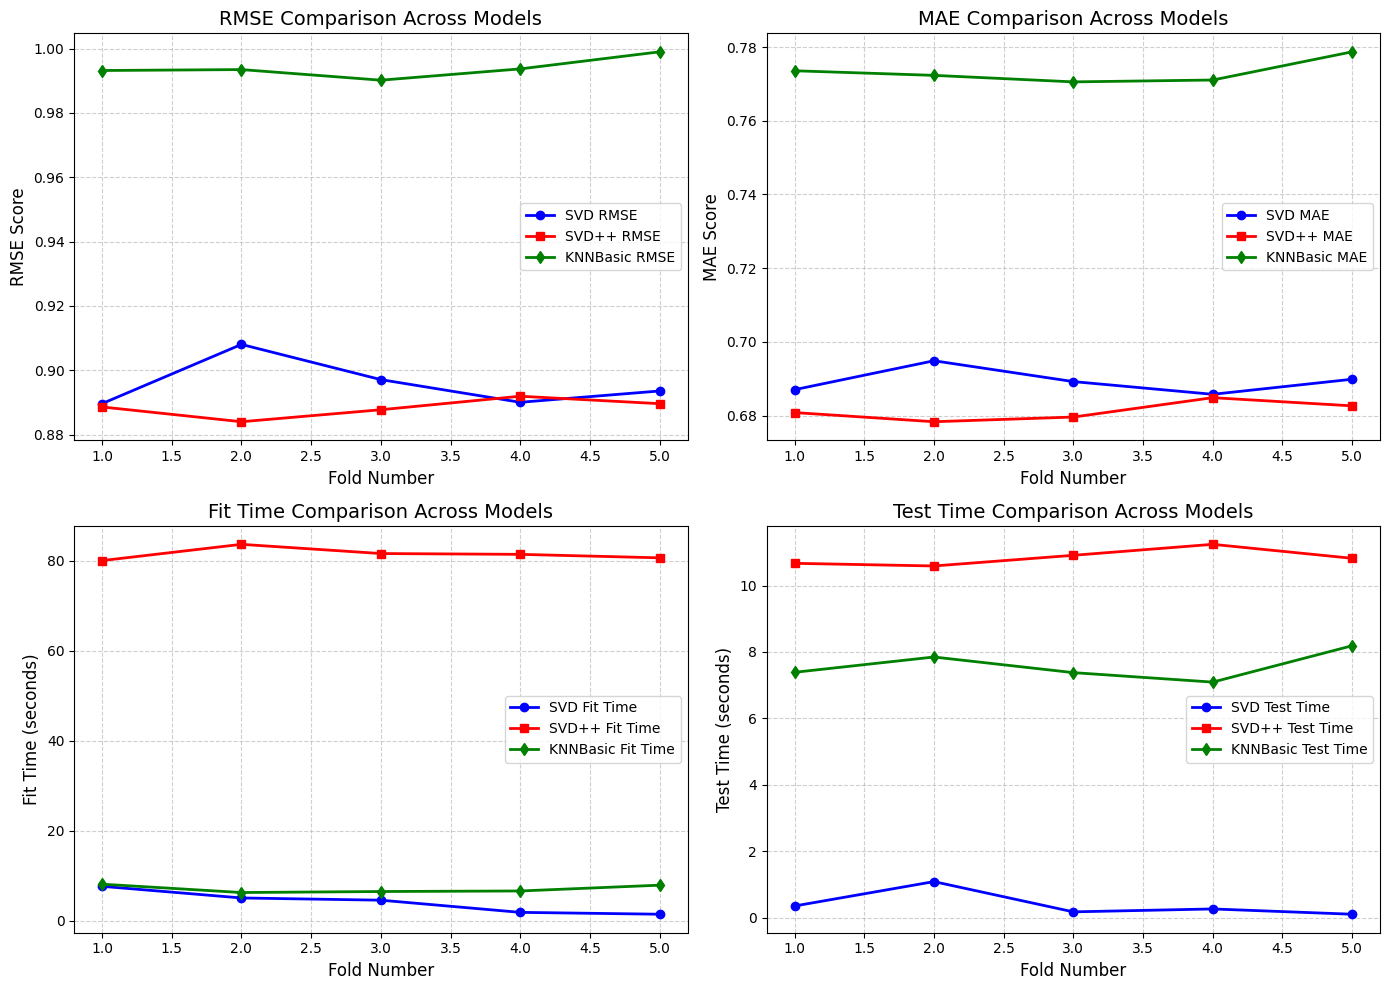

In [ ]:
num_folds = len(cv_results['test_rmse'])
folds = np.arange(1, num_folds + 1)

# Extract RMSE, MAE, Fit Time, and Test Time values
svd_rmse, svd_mae, svd_fit_time, svd_test_time = cv_results['test_rmse'], cv_results['test_mae'], cv_results['fit_time'], cv_results['test_time']
svdpp_rmse, svdpp_mae, svdpp_fit_time, svdpp_test_time = svdpp_results['test_rmse'], svdpp_results['test_mae'], svdpp_results['fit_time'], svdpp_results['test_time']
knn_rmse, knn_mae, knn_fit_time, knn_test_time = cv_results_knn['test_rmse'], cv_results_knn['test_mae'], cv_results_knn['fit_time'], cv_results_knn['test_time']

# Create a figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot RMSE comparison
axes[0, 0].plot(folds, svd_rmse, marker='o', linestyle='-', color='b', label='SVD RMSE', linewidth=2)
axes[0, 0].plot(folds, svdpp_rmse, marker='s', linestyle='-', color='r', label='SVD++ RMSE', linewidth=2)
axes[0, 0].plot(folds, knn_rmse, marker='d', linestyle='-', color='g', label='KNNBasic RMSE', linewidth=2)
axes[0, 0].set_xlabel('Fold Number', fontsize=12)
axes[0, 0].set_ylabel('RMSE Score', fontsize=12)
axes[0, 0].set_title('RMSE Comparison Across Models', fontsize=14)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# Plot MAE comparison
axes[0, 1].plot(folds, svd_mae, marker='o', linestyle='-', color='b', label='SVD MAE', linewidth=2)
axes[0, 1].plot(folds, svdpp_mae, marker='s', linestyle='-', color='r', label='SVD++ MAE', linewidth=2)
axes[0, 1].plot(folds, knn_mae, marker='d', linestyle='-', color='g', label='KNNBasic MAE', linewidth=2)
axes[0, 1].set_xlabel('Fold Number', fontsize=12)
axes[0, 1].set_ylabel('MAE Score', fontsize=12)
axes[0, 1].set_title('MAE Comparison Across Models', fontsize=14)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# Plot Fit Time comparison
axes[1, 0].plot(folds, svd_fit_time, marker='o', linestyle='-', color='b', label='SVD Fit Time', linewidth=2)
axes[1, 0].plot(folds, svdpp_fit_time, marker='s', linestyle='-', color='r', label='SVD++ Fit Time', linewidth=2)
axes[1, 0].plot(folds, knn_fit_time, marker='d', linestyle='-', color='g', label='KNNBasic Fit Time', linewidth=2)
axes[1, 0].set_xlabel('Fold Number', fontsize=12)
axes[1, 0].set_ylabel('Fit Time (seconds)', fontsize=12)
axes[1, 0].set_title('Fit Time Comparison Across Models', fontsize=14)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# Plot Test Time comparison
axes[1, 1].plot(folds, svd_test_time, marker='o', linestyle='-', color='b', label='SVD Test Time', linewidth=2)
axes[1, 1].plot(folds, svdpp_test_time, marker='s', linestyle='-', color='r', label='SVD++ Test Time', linewidth=2)
axes[1, 1].plot(folds, knn_test_time, marker='d', linestyle='-', color='g', label='KNNBasic Test Time', linewidth=2)
axes[1, 1].set_xlabel('Fold Number', fontsize=12)
axes[1, 1].set_ylabel('Test Time (seconds)', fontsize=12)
axes[1, 1].set_title('Test Time Comparison Across Models', fontsize=14)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

# Adjust layout for better spacing
plt.tight_layout()

# Show the final plots
plt.show()

#### **Conclusion:**

Based on the `cross-validation` results, `SVD` is the best candidate for hyperparameter tuning as it offers a balance between accuracy and computational efficiency. While `SVD++` provides slightly better accuracy, its high training cost makes it less scalable. `SVD`, on the other hand, delivers competitive performance while maintaining a low computational footprint, making it ideal for real-world applications.

#### **Fine-Tuning the Hyper-parameters**

In [ ]:
# Define hyperparameter grid
param_grid = {
    'n_factors': [50, 100, 150],  # Test different latent factor sizes
    'n_epochs': [20, 30, 40],  # Increase training epochs
    'reg_all': [0.02, 0.05, 0.1]  # Adjust regularization
}

# Run Grid Search
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=5)
gs.fit(data)

# Print the best hyperparameters
print("Best RMSE: ", gs.best_score['rmse'])
print("Best Hyperparameters: ", gs.best_params['rmse'])

Best RMSE:  0.8820485666198499
Best Hyperparameters:  {'n_factors': 150, 'n_epochs': 40, 'reg_all': 0.1}


* **Train `SVD` with the `best parameters`**

In [ ]:
best_svd1 = SVD(**gs.best_params['rmse'])

# Cross-validate the model
cv_results1 = cross_validate(best_svd1, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)


Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8863  0.8772  0.8794  0.8835  0.8839  0.8821  0.0033  
MAE (testset)     0.6845  0.6766  0.6757  0.6797  0.6807  0.6794  0.0031  
Fit time          4.57    3.64    3.70    4.66    3.65    4.04    0.47    
Test time         0.11    0.11    0.46    0.11    0.14    0.19    0.14    


####**Comparasion between SVD model before and after fine-tuning**

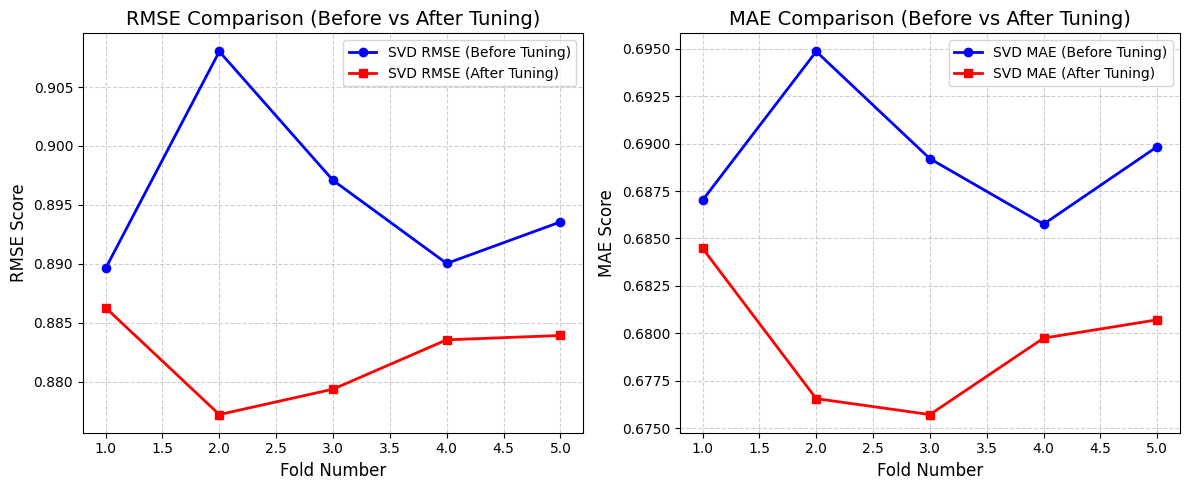

In [ ]:
# Define the number of folds dynamically
num_folds = len(cv_results['test_rmse'])
folds = np.arange(1, num_folds + 1)

# Extract RMSE and MAE scores for both models
svd_rmse = cv_results['test_rmse']
svd_mae = cv_results['test_mae']
svd_tuned_rmse = cv_results1['test_rmse']
svd_tuned_mae = cv_results1['test_mae']

# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot RMSE comparison
axes[0].plot(folds, svd_rmse, marker='o', linestyle='-', color='b', label='SVD RMSE (Before Tuning)', linewidth=2)
axes[0].plot(folds, svd_tuned_rmse, marker='s', linestyle='-', color='r', label='SVD RMSE (After Tuning)', linewidth=2)
axes[0].set_xlabel('Fold Number', fontsize=12)
axes[0].set_ylabel('RMSE Score', fontsize=12)
axes[0].set_title('RMSE Comparison (Before vs After Tuning)', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot MAE comparison
axes[1].plot(folds, svd_mae, marker='o', linestyle='-', color='b', label='SVD MAE (Before Tuning)', linewidth=2)
axes[1].plot(folds, svd_tuned_mae, marker='s', linestyle='-', color='r', label='SVD MAE (After Tuning)', linewidth=2)
axes[1].set_xlabel('Fold Number', fontsize=12)
axes[1].set_ylabel('MAE Score', fontsize=12)
axes[1].set_title('MAE Comparison (Before vs After Tuning)', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)

# Adjust layout for better spacing
plt.tight_layout()

# Show the final plots
plt.show()

#### **Conclusion**:
* Hyperparameter tuning successfully improved the SVD model, reducing both `RMSE` and `MAE`.
* The tuned model is now more accurate while still being computationally efficient.

#### **Training the Optimized SVD Model on the Full Dataset**

* Lets train the optimized SVD model (best_svd1) using the entire dataset to maximize learning before making predictions.

* `data.build_full_trainset()` converts the dataset into a fully populated training set, **including all available user-movie interactions.**
`best_svd1.fit(trainset)` trains the `best SVD` model (after hyperparameter tuning) on this complete dataset, allowing it to learn user preferences more effectively.

* This step ensures that the final model benefits from all available data, improving its ability to generate accurate recommendations.

In [ ]:
trainset = data.build_full_trainset()
best_svd1.fit(trainset)

* Now lets do some `predictions(^_^)`!

In [ ]:
ratings_df[ratings_df['userId'] == 1]


,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205
5,1,1263,2.0,1260759151
6,1,1287,2.0,1260759187
7,1,1293,2.0,1260759148
8,1,1339,3.5,1260759125
9,1,1343,2.0,1260759131


In [ ]:
best_svd1.predict(1, 3050)

Prediction(uid=1, iid=3050, r_ui=None, est=2.6464665463659838, details={'was_impossible': False})

* As we can see, the `singular value decomposition (SVD)` recommender system is that it doesn't care what the movie is (or what it contains). It works purely on the basis of the movie id and tries to predict ratings based on how the other users have predicted the movie.

* so, No content similarity, just rating predictions.
* we will handel this issue using `Hybrid Technique` by combing the collaboative filtering with `content-based filtering`, also the `demographic filtering`.

## **Hybrid Recommendation**

* lets combine demograhic, content-based, and collaborative filtering togther.

The `hybrid_recommendations()`, implements a `hybrid recommendation` approach by combining `content-based filtering` and `collaborative filtering (SVD)` to provide personalized and high-quality movie recommendations.

Key Steps in the `Hybrid Recommendation` Process:
1. **`Content-Based Filtering`**:

  * Retrieves `top 50` similar movies to the given title using cosine similarity.
  * Filters movies based on vote count and `IMDb weighted rating` to **prioritize high-quality films**.

2. **`User-Based Personalization (Collaborative Filtering - SVD)`**:

  * If the user has prior interactions, the SVD model predicts movie ratings for the user.
  * If the user is new, recommendations are **based purely on content similarity and IMDb rating**.

3. Final Recommendation Ranking:

  * A weighted score is computed using `70% SVD-predicted rating and 30% IMDb weighted rating`.
  * The `top 10 movies` are returned based on this final ranking.
  * This hybrid approach ensures that recommendations are **both relevant and personalized**, leveraging metadata-based similarities while incorporating user preferences when available.

In [ ]:
links_df = pd.read_csv("/content/drive/MyDrive/Recommedation System/the movie dataset/links_small.csv")
links_df.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [ ]:
def hybrid_recommendations(user_id, title, best_svd_model=best_svd1, ratings_df=ratings_df, cosine_sim=cosine_similarity2):

    # Validate if the title exists
    index = indices.get(title, None)
    if index is None:
        raise ValueError(f"Movie title '{title}' not found in the dataset.")

    # Get top similar movies using content-based filtering
    similarity_scores = list(enumerate(cosine_sim[index]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    # Retrieve top 50 most similar movies (not including the original)
    similar_movie_indices = [i[0] for i in similarity_scores[1:52]]
    recommended_movies = new_df.iloc[similar_movie_indices][['title_x', 'id', 'vote_count', 'vote_average', 'release_date']]

    recommended_movies = recommended_movies.copy()
    recommended_movies['vote_count'] = recommended_movies['vote_count'].fillna(0).astype(int)
    recommended_movies['vote_average'] = recommended_movies['vote_average'].fillna(0).astype(float)

    # Compute the mean vote average and the minimum vote count threshold
    C = recommended_movies['vote_average'].mean()
    m = recommended_movies['vote_count'].quantile(0.65)

    # Apply IMDB Weighted Rating Before SVD
    recommended_movies.loc[:, 'weighted_rating'] = recommended_movies.apply(lambda x: weighted_rating(x, C, m), axis=1)

    # Filter movies that meet the minimum vote count requirement Before SVD
    qualified_movies = recommended_movies.loc[recommended_movies['vote_count'] >= m].copy()

    # Fix: Match TMDb ID to MovieLens movieId before SVD predictions
    qualified_movies = qualified_movies.merge(links_df[['tmdbId', 'movieId']], left_on='id', right_on='tmdbId', how='left')
    qualified_movies = qualified_movies.dropna(subset=['movieId'])  # Drop rows without MovieLens ID
    qualified_movies['movieId'] = qualified_movies['movieId'].astype(int)  # Convert to integer


    # Check if the user exists in ratings_df
    if user_id not in ratings_df['userId'].unique():
        print(f"User {user_id} is new, skipping SVD model.")
        return qualified_movies.sort_values('weighted_rating', ascending=False).head(10)

    # Convert 'id' column to integer before predictions
    qualified_movies['movieId'] = qualified_movies['id'].astype(int)

    # Predict ratings using the trained SVD model
    predicted_ratings = []
    for movie_id in qualified_movies['movieId']:
        try:
            prediction = best_svd_model.predict(user_id, movie_id)
            predicted_ratings.append(prediction.est)  # Extract predicted rating
        except PredictionImpossible:
            predicted_ratings.append(C)  # Default to average rating if prediction fails

    # Add predicted ratings to DataFrame
    qualified_movies.loc[:, 'predicted_rating'] = predicted_ratings

    # Compute final score as a weighted sum of SVD predicted rating & IMDB rating
    qualified_movies.loc[:, 'final_score'] = (0.7 * qualified_movies['predicted_rating']) + (0.3 * qualified_movies['weighted_rating'])

    # Sort by final score and return top 10 recommendations
    return qualified_movies.sort_values('final_score', ascending=False).head(10)


In [ ]:
hybrid_recommendations(1, "Iron Man")

,title_x,id,vote_count,vote_average,release_date,weighted_rating,tmdbId,movieId,predicted_rating,final_score
9,Guardians of the Galaxy,118340,9742,7.9,2014-07-30,7.370531,118340.0,118340,2.646467,4.063686
2,The Avengers,24428,11776,7.4,2012-04-25,7.070327,24428.0,24428,2.646467,3.973625
10,Deadpool,293660,10995,7.4,2016-02-09,7.053438,293660.0,293660,2.646467,3.968558
6,Captain America: The Winter Soldier,100402,5764,7.6,2014-03-20,6.987524,100402.0,100402,2.646467,3.948784
12,X-Men: Days of Future Past,127585,6032,7.5,2014-05-15,6.944823,127585.0,127585,2.646467,3.935973
5,Avengers: Age of Ultron,99861,6767,7.3,2015-04-22,6.859015,99861.0,99861,2.646467,3.910231
7,Captain America: The First Avenger,1771,7047,6.6,2011-07-22,6.433289,1771.0,1771,2.816518,3.901549
4,Captain America: Civil War,271110,7241,7.1,2016-04-27,6.751176,271110.0,271110,2.646467,3.877879
13,X-Men: First Class,49538,5181,7.1,2011-05-24,6.674983,49538.0,49538,2.646467,3.855022
3,Ant-Man,102899,5880,7.0,2015-07-14,6.646265,102899.0,102899,2.646467,3.846406


In [ ]:
hybrid_recommendations(2000, "Iron Man")

User 2000 is new, skipping SVD model.


,title_x,id,vote_count,vote_average,release_date,weighted_rating,tmdbId,movieId
9,Guardians of the Galaxy,118340,9742,7.9,2014-07-30,7.370531,118340.0,112852
2,The Avengers,24428,11776,7.4,2012-04-25,7.070327,24428.0,89745
10,Deadpool,293660,10995,7.4,2016-02-09,7.053438,293660.0,122904
6,Captain America: The Winter Soldier,100402,5764,7.6,2014-03-20,6.987524,100402.0,110102
12,X-Men: Days of Future Past,127585,6032,7.5,2014-05-15,6.944823,127585.0,111362
5,Avengers: Age of Ultron,99861,6767,7.3,2015-04-22,6.859015,99861.0,122892
4,Captain America: Civil War,271110,7241,7.1,2016-04-27,6.751176,271110.0,122920
13,X-Men: First Class,49538,5181,7.1,2011-05-24,6.674983,49538.0,87232
3,Ant-Man,102899,5880,7.0,2015-07-14,6.646265,102899.0,122900
1,Iron Man 3,68721,8806,6.8,2013-04-18,6.590645,68721.0,102125


* **Improved Hybrid Recommender System to include a `Dynamic Weighting for Hybrid Score`**

In [ ]:
def improved_hybrid_recommendations(user_id, title, best_svd_model=best_svd1, ratings_df=ratings_df,
                           cosine_sim=cosine_similarity2, links_df=links_df, top_n=10):
    # Validate if the title exists
    index = indices.get(title, None)
    if index is None:
        raise ValueError(f"Movie title '{title}' not found in the dataset.")

    # Get top similar movies using content-based filtering
    similarity_scores = np.array(cosine_sim[index])
    similar_movie_indices = similarity_scores.argsort()[::-1][1:52]

    recommended_movies = new_df.iloc[similar_movie_indices][['title_x', 'id', 'vote_count', 'vote_average', 'release_date', 'genres']]
    recommended_movies = recommended_movies.copy()
    recommended_movies['vote_count'] = recommended_movies['vote_count'].fillna(0).astype(int)
    recommended_movies['vote_average'] = recommended_movies['vote_average'].fillna(0).astype(float)

    # Compute IMDb weighted rating after filtering out low vote count movies
    C = recommended_movies['vote_average'].mean()
    m = recommended_movies['vote_count'].quantile(0.60)

    # Apply IMDb weighted rating formula
    recommended_movies['weighted_rating'] = recommended_movies.apply(lambda x: weighted_rating(x, C, m), axis=1)

    # Filter movies that meet the minimum vote count threshold
    qualified_movies = recommended_movies.loc[recommended_movies['vote_count'] >= m].copy()

    # Match TMDb ID to MovieLens movieId before SVD predictions
    qualified_movies = qualified_movies.merge(links_df[['tmdbId', 'movieId']], left_on='id', right_on='tmdbId', how='left')
    qualified_movies = qualified_movies.dropna(subset=['movieId'])  # Drop rows without MovieLens ID
    qualified_movies['movieId'] = qualified_movies['movieId'].astype(int)  # Convert to integer

    # Cold-Start Handling: New User Recommendations
    if user_id not in ratings_df['userId'].unique():
        print(f"User {user_id} is new. Using content and genre-based recommendations.")
        return qualified_movies.sort_values('weighted_rating', ascending=False).head(top_n)[['title_x','weighted_rating']]

    # Count user's past ratings
    user_ratings_count = ratings_df[ratings_df['userId'] == user_id].shape[0]

    # Predict ratings using SVD for known users
    predicted_ratings = []
    for movie_id in qualified_movies['movieId']:
        try:
            prediction = best_svd_model.predict(user_id, movie_id)
            predicted_ratings.append(prediction.est)
        except PredictionImpossible:
            # Use a weighted average of nearest neighbors' ratings instead of global average (C)
            nearest_neighbors = ratings_df[ratings_df['movieId'] == movie_id]['rating']
            predicted_ratings.append(nearest_neighbors.mean() if not nearest_neighbors.empty else C)

    qualified_movies['predicted_rating'] = predicted_ratings

    # Dynamic Weighting for Hybrid Score
    if user_ratings_count < 10:
        svd_weight = 0.5  # Less confidence in SVD for new users
    elif user_ratings_count < 50:
        svd_weight = 0.6
    else:
        svd_weight = 0.7  # Higher confidence for active users

    imdb_weight = 1 - svd_weight  # Remaining weight goes to IMDb rating
    qualified_movies['final_score'] = (svd_weight * qualified_movies['predicted_rating']) + (imdb_weight * qualified_movies['weighted_rating'])

    # Return dynamic number of recommendations based on available data
    return qualified_movies.sort_values('final_score', ascending=False).head(min(top_n, len(qualified_movies)))[['title_x','weighted_rating','predicted_rating','final_score']]

* Lets do some improvements to include a weight for the `popularity` and the `similarity`

In [ ]:
def improved_hybrid_recommendations(user_id, title, best_svd_model=best_svd1, ratings_df=ratings_df,
                           cosine_sim=cosine_similarity2, links_df=links_df, top_n=10,
                           popularity_weight=0.15, similarity_weight=0.85):
    # Validate if the title exists
    index = indices.get(title, None)
    if index is None:
        raise ValueError(f"Movie title '{title}' not found in the dataset.")

    # Get top similar movies using content-based filtering
    similarity_scores = np.array(cosine_sim[index])
    similar_movie_indices = similarity_scores.argsort()[::-1][1:62]

    recommended_movies = new_df.iloc[similar_movie_indices][['title_x', 'id', 'vote_count', 'vote_average', 'release_date', 'genres']]
    recommended_movies = recommended_movies.copy()
    recommended_movies['vote_count'] = recommended_movies['vote_count'].fillna(0).astype(int)
    recommended_movies['vote_average'] = recommended_movies['vote_average'].fillna(0).astype(float)

    # Compute IMDb weighted rating after filtering out low vote count movies
    C = recommended_movies['vote_average'].mean()
    m = recommended_movies['vote_count'].quantile(0.65)

    # Apply IMDb weighted rating formula
    recommended_movies['weighted_rating'] = recommended_movies.apply(lambda x: weighted_rating(x, C, m), axis=1)

    # Filter movies that meet the minimum vote count threshold
    qualified_movies = recommended_movies.loc[recommended_movies['vote_count'] >= m].copy()

    # Recompute the similarity scores only for the qualified movies
    filtered_indices = [i for i in similar_movie_indices if i in qualified_movies.index]
    filtered_similarity_scores = similarity_scores[filtered_indices]


    # Reset index to align indices properly
    qualified_movies = qualified_movies.reset_index(drop=True)

    # Keep only the indices that are still present in qualified_movies
    filtered_similarity_scores = pd.DataFrame({
    "id": new_df.iloc[similar_movie_indices]["id"].values,
    "similarity_score": similarity_scores[similar_movie_indices]
    })

    # Merge to assign similarity scores properly
    qualified_movies = qualified_movies.merge(filtered_similarity_scores, on="id", how="left")

    # Fill missing similarity scores (if any) with the minimum similarity
    qualified_movies["similarity_score"] = qualified_movies["similarity_score"].fillna(qualified_movies["similarity_score"].min())


    # Cold-Start Handling: New User Recommendations
    if user_id not in ratings_df['userId'].unique():
        print(f"User {user_id} is new. Using content and genre-based recommendations.")

        # Compute Final Score for Sorting
        qualified_movies['final_score'] = (
            (popularity_weight * qualified_movies['weighted_rating']) +
            (similarity_weight * qualified_movies['similarity_score'])
        )

        # Sort based on new weighted score
        return qualified_movies.sort_values('final_score', ascending=False).head(top_n)[['title_x', 'weighted_rating', 'similarity_score', 'final_score']]

    # Match TMDb ID to MovieLens movieId before SVD predictions
    qualified_movies = qualified_movies.merge(links_df[['tmdbId', 'movieId']], left_on='id', right_on='tmdbId', how='left')
    qualified_movies = qualified_movies.dropna(subset=['movieId'])  # Drop rows without MovieLens ID
    qualified_movies['movieId'] = qualified_movies['movieId'].astype(int)  # Convert to integer

    # Count user's past ratings
    user_ratings_count = ratings_df[ratings_df['userId'] == user_id].shape[0]

    # Predict ratings using SVD for known users
    predicted_ratings = []
    for movie_id in qualified_movies['movieId']:
        try:
            prediction = best_svd_model.predict(user_id, movie_id)
            predicted_ratings.append(prediction.est)
        except PredictionImpossible:
            # Use a weighted average of nearest neighbors' ratings instead of global average (C)
            nearest_neighbors = ratings_df[ratings_df['movieId'] == movie_id]['rating']
            predicted_ratings.append(nearest_neighbors.mean() if not nearest_neighbors.empty else C)

    qualified_movies['predicted_rating'] = predicted_ratings

    # Dynamic Weighting for Hybrid Score
    if user_ratings_count < 10:
        svd_weight = 0.5  # Less confidence in SVD for new users
    elif user_ratings_count < 50:
        svd_weight = 0.6
    else:
        svd_weight = 0.7  # Higher confidence for active users

    imdb_weight = 1 - svd_weight  # Remaining weight goes to IMDb rating
    qualified_movies['final_score'] = (svd_weight * qualified_movies['predicted_rating']) + (imdb_weight * qualified_movies['weighted_rating'])

    # Return final recommendations
    return qualified_movies.sort_values('final_score', ascending=False).head(min(top_n, len(qualified_movies)))[['title_x', 'weighted_rating', 'predicted_rating', 'final_score']]


#### **Now, Lets do some testing(^_^)!**

* For the user with id: 1, watching movie("Iron Man")

In [ ]:
improved_hybrid_recommendations(1, "Iron Man",top_n=10)

,title_x,weighted_rating,predicted_rating,final_score
10,Guardians of the Galaxy,7.339627,3.011663,4.742849
6,Captain America: The Winter Soldier,6.935094,3.241420,4.718889
2,The Avengers,7.039051,2.999481,4.615309
5,Avengers: Age of Ultron,6.808731,3.009240,4.529036
15,X-Men: First Class,6.611453,3.054724,4.477416
16,X-Men: Days of Future Past,6.892817,2.833408,4.457172
3,Ant-Man,6.586556,3.005892,4.438158
11,Deadpool,7.020278,2.706537,4.432033
7,Captain America: The First Avenger,6.375469,2.915979,4.299775
4,Captain America: Civil War,6.700816,2.637180,4.262635


In [ ]:
improved_hybrid_recommendations(2, "Iron Man",top_n=10)


,title_x,weighted_rating,predicted_rating,final_score
6,Captain America: The Winter Soldier,6.935094,4.113797,4.960186
10,Guardians of the Galaxy,7.339627,3.874282,4.913885
2,The Avengers,7.039051,3.861465,4.814741
5,Avengers: Age of Ultron,6.808731,3.814157,4.712529
3,Ant-Man,6.586556,3.865764,4.682001
16,X-Men: Days of Future Past,6.892817,3.703552,4.660331
15,X-Men: First Class,6.611453,3.815692,4.654421
7,Captain America: The First Avenger,6.375469,3.680676,4.489114
11,Deadpool,7.020278,3.337795,4.442540
8,X-Men,6.394813,3.584752,4.427770


In [ ]:
improved_hybrid_recommendations(2000, "Iron Man", top_n=10)

User 2000 is new. Using content and genre-based recommendations.


,title_x,weighted_rating,similarity_score,final_score
0,Iron Man 2,6.371379,0.674453,1.528992
2,The Avengers,7.039051,0.500773,1.481515
1,Iron Man 3,6.543564,0.586939,1.480433
4,Captain America: Civil War,6.700816,0.486664,1.418787
5,Avengers: Age of Ultron,6.808731,0.458831,1.411316
3,Ant-Man,6.586556,0.490511,1.404918
10,Guardians of the Galaxy,7.339627,0.344124,1.393449
6,Captain America: The Winter Soldier,6.935094,0.410391,1.389097
11,Deadpool,7.020278,0.344124,1.345547
16,X-Men: Days of Future Past,6.892817,0.324443,1.309699


In [ ]:
improved_hybrid_recommendations(2000, "The Dark Knight Rises", top_n=10)


User 2000 is new. Using content and genre-based recommendations.


,title_x,weighted_rating,similarity_score,final_score
1,The Dark Knight,8.132190,0.565217,1.700263
0,Batman Begins,7.424324,0.577920,1.604881
14,The Prestige,7.838900,0.245737,1.384711
6,Batman,6.836165,0.269191,1.254237
5,Batman Returns,6.473443,0.273009,1.203074
7,Kick-Ass 2,6.242493,0.269191,1.165186
18,Payback,6.377310,0.240772,1.161252
16,Panic Room,6.364190,0.240772,1.159284
20,Colombiana,6.313504,0.240772,1.151682
11,Gangster Squad,6.147468,0.263752,1.146310


* **Some testings as above:**

In [ ]:
improved_hybrid_recommendations(2000, "Interstellar", top_n=10)

User 2000 is new. Using content and genre-based recommendations.


,title_x,weighted_rating,similarity_score,final_score
0,The Martian,7.314211,0.318182,1.367586
3,Guardians of the Galaxy,7.606124,0.213201,1.322139
10,The Matrix,7.584968,0.181818,1.292291
12,Alien,7.389799,0.177822,1.259618
7,Blade Runner,7.310731,0.190693,1.258698
8,2001: A Space Odyssey,7.257810,0.186097,1.246854
5,The Terminator,7.001047,0.195646,1.216456
9,Gravity,7.058515,0.184637,1.215719
11,Avatar,7.077887,0.177822,1.212832
2,Oblivion,6.451247,0.227921,1.161420


In [ ]:
improved_hybrid_recommendations(2000, "Gravity",top_n=10)


User 2000 is new. Using content and genre-based recommendations.


,title_x,weighted_rating,similarity_score,final_score
8,The Martian,7.531666,0.246183,1.339005
3,Children of Men,7.204708,0.251976,1.294886
21,Moon,7.351483,0.223607,1.292788
20,Sunshine,6.763169,0.223607,1.204541
18,10 Cloverfield Lane,6.694429,0.223607,1.194230
2,Elysium,6.352292,0.261116,1.174793
9,Armageddon,6.335774,0.240772,1.155022
13,The Ides of March,6.327415,0.231455,1.145849
1,Appaloosa,6.042993,0.261116,1.128398
16,Flatliners,6.082330,0.231455,1.109086


In [ ]:
improved_hybrid_recommendations(2000, "Mission to Mars",top_n=10)


User 2000 is new. Using content and genre-based recommendations.


,title_x,weighted_rating,similarity_score,final_score
9,Alien,7.426154,0.161515,1.251210
1,Gravity,7.037736,0.223607,1.245726
8,The Martian,7.329460,0.165145,1.239792
6,2001: A Space Odyssey,7.273460,0.169031,1.234695
5,Aliens,7.168052,0.169031,1.218884
3,Star Trek Into Darkness,7.053134,0.187867,1.217657
7,Star Trek,7.058832,0.165145,1.199198
10,Avatar,7.068135,0.161515,1.197508
21,Edge of Tomorrow,7.228029,0.129099,1.193939
0,Alien³,6.139734,0.269191,1.149772


In [ ]:
improved_hybrid_recommendations(2000, "The Dark Knight", top_n=60)

User 2000 is new. Using content and genre-based recommendations.


,title_x,weighted_rating,similarity_score,final_score
1,The Dark Knight Rises,7.533195,0.565217,1.610414
0,Batman Begins,7.422783,0.577920,1.604650
8,The Equalizer,6.964012,0.266733,1.271324
6,Batman,6.831325,0.269191,1.253511
5,Batman Returns,6.467597,0.273009,1.202198
7,Kick-Ass 2,6.237892,0.269191,1.164496
18,Payback,6.364246,0.240772,1.159293
17,Colombiana,6.303478,0.240772,1.150178
12,Gangster Squad,6.141909,0.263752,1.145476
4,Faster,6.005401,0.278019,1.137126


In [ ]:
improved_hybrid_recommendations(1, "Iron Man",top_n=20)

,title_x,weighted_rating,predicted_rating,final_score
10,Guardians of the Galaxy,7.339627,3.011663,4.742849
6,Captain America: The Winter Soldier,6.935094,3.241420,4.718889
2,The Avengers,7.039051,2.999481,4.615309
5,Avengers: Age of Ultron,6.808731,3.009240,4.529036
15,X-Men: First Class,6.611453,3.054724,4.477416
16,X-Men: Days of Future Past,6.892817,2.833408,4.457172
3,Ant-Man,6.586556,3.005892,4.438158
11,Deadpool,7.020278,2.706537,4.432033
7,Captain America: The First Avenger,6.375469,2.915979,4.299775
4,Captain America: Civil War,6.700816,2.637180,4.262635


### Lets do some improvements to make a precedence to the modern movies.

The `_apply_recency_boost` function is a helper method designed to assign a recency score to movies based on their release dates. The function converts release dates into numerical years, handles missing or invalid dates, and scales these values to generate a `recency_score` between 0 and 1. This score indicates how recent a movie is within the dataset, with 1 representing the most recent release and 0 representing the oldest.

### **Methodology:**
1. **Year Extraction:** The function uses `pd.to_datetime()` to parse the `release_date` column into a numeric year format. Any invalid dates are converted to `NaT` (Not a Time), allowing for robust date handling.

2. **Handling Missing Values:** Missing or invalid years are filled with the earliest available year in the dataset (`df['year'].min()`). This approach prevents null values and ensures all rows are considered during scoring.

3. **Scaling to Recency Score:** The function normalizes the year values using the formula:
$\boxed{\text{recency_score} = \frac{\text{year} - \text{min_year}}{\text{max_year} - \text{min_year}}}$

- **Min-Max Scaling:** The formula applies a min-max scaling approach to convert the year into a `recency_score` that falls within a 0 to 1 range.
- **Edge Case Handling:** When the minimum and maximum years are the same, the function avoids division by zero by setting the range to 1.

4. **Output:** A new `recency_score` column is added to the DataFrame (`df`), which can be used to boost the visibility of newer movies in recommendation algorithms.

In [ ]:
def _apply_recency_boost(df):
    # Parse year from release_date
    df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

    # Fallback for rows with missing/invalid release_date
    df['year'] = df['year'].fillna(df['year'].min())

    # Scale years to [0,1] range
    min_year = df['year'].min()
    max_year = df['year'].max()
    year_range = max_year - min_year if max_year != min_year else 1

    df['recency_score'] = (df['year'] - min_year) / year_range

    return df

In [ ]:
def improved_hybrid_recommendations2(
    user_id, title, best_svd_model=best_svd1, ratings_df=ratings_df,
    cosine_sim=cosine_similarity2, links_df=links_df, top_n=10,
    popularity_weight=0.15, similarity_weight=0.85,
    recency_weight=0.2
):
    # Validate the title
    index = indices.get(title, None)
    if index is None:
        raise ValueError(f"Movie title '{title}' not found in the dataset.")

    # Get top content-based similar movies
    similarity_scores = np.array(cosine_sim[index])
    similar_movie_indices = similarity_scores.argsort()[::-1][1:62]

    recommended_movies = new_df.iloc[similar_movie_indices][
        ['title_x','id','vote_count','vote_average','release_date']
    ].copy()
    recommended_movies['vote_count']   = recommended_movies['vote_count'].fillna(0).astype(int)
    recommended_movies['vote_average'] = recommended_movies['vote_average'].fillna(0).astype(float)

    # IMDb Weighted Rating
    C = recommended_movies['vote_average'].mean()
    m = recommended_movies['vote_count'].quantile(0.65)
    recommended_movies['weighted_rating'] = recommended_movies.apply(
        lambda x: weighted_rating(x, C, m), axis=1
    )

    qualified_movies = recommended_movies.copy()
    qualified_movies.reset_index(drop=True, inplace=True)

    # Merge similarity scores
    similarity_df = pd.DataFrame({
        "id": new_df.iloc[similar_movie_indices]["id"].values,
        "similarity_score": similarity_scores[similar_movie_indices]
    })
    qualified_movies = qualified_movies.merge(similarity_df, on="id", how="left")
    qualified_movies["similarity_score"] = qualified_movies["similarity_score"].fillna(
        qualified_movies["similarity_score"].min()
    )

    # Cold-Start Handling (new user)
    if user_id not in ratings_df['userId'].unique():
        print(f"User {user_id} is new. Using content and genre-based recommendations.")

        # Incorporate recency
        qualified_movies = _apply_recency_boost(qualified_movies)

        # Final Score (no SVD for new user)
        qualified_movies['final_score'] = (
            (popularity_weight * qualified_movies['weighted_rating'])
            + (similarity_weight * qualified_movies['similarity_score'])
        )

        # Combine recency into final_score
        qualified_movies['final_score'] = (
            qualified_movies['final_score'] * (1 - recency_weight)
            + qualified_movies['recency_score'] * recency_weight
        )

        return qualified_movies\
                 .sort_values('final_score', ascending=False)\
                 .head(top_n)[['title_x','release_date',
                               'weighted_rating','similarity_score','final_score']]

    # Match TMDb ID -> MovieLens movieId
    qualified_movies = qualified_movies.merge(
        links_df[['tmdbId','movieId']],
        left_on='id',
        right_on='tmdbId',
        how='left'
    )
    qualified_movies.dropna(subset=['movieId'], inplace=True)
    qualified_movies['movieId'] = qualified_movies['movieId'].astype(int)

    # Predict user ratings with SVD
    user_ratings_count = ratings_df[ratings_df['userId'] == user_id].shape[0]

    predicted_ratings = []
    for movie_id in qualified_movies['movieId']:
        try:
            prediction = best_svd_model.predict(user_id, movie_id)
            predicted_ratings.append(prediction.est)
        except PredictionImpossible:
            nearest_neighbors = ratings_df[ratings_df['movieId'] == movie_id]['rating']
            predicted_ratings.append(nearest_neighbors.mean() if not nearest_neighbors.empty else C)

    qualified_movies['predicted_rating'] = predicted_ratings

    # Dynamic Weighting
    if user_ratings_count < 10:
        svd_weight = 0.5
    elif user_ratings_count < 50:
        svd_weight = 0.6
    else:
        svd_weight = 0.7

    imdb_weight = 1 - svd_weight
    qualified_movies['final_score'] = (
        svd_weight * qualified_movies['predicted_rating']
        + imdb_weight * qualified_movies['weighted_rating']
    )

    # Recency Boost
    qualified_movies = _apply_recency_boost(qualified_movies)

    # Combine recency with final_score
    qualified_movies['final_score'] = (
        qualified_movies['final_score'] * (1 - recency_weight)
        + qualified_movies['recency_score'] * recency_weight
    )

    # Sort & Return
    return qualified_movies\
             .sort_values('final_score', ascending=False)\
             .head(min(top_n, len(qualified_movies)))[
                 ['title_x','release_date','weighted_rating',
                  'predicted_rating','final_score']
             ]

In [ ]:
improved_hybrid_recommendations2(2000, 'Iron Man',top_n=10)

User 2000 is new. Using content and genre-based recommendations.


,title_x,release_date,weighted_rating,similarity_score,final_score
0,Iron Man 2,2010-04-28,6.371379,0.674453,1.391615
1,Iron Man 3,2013-04-18,6.543564,0.586939,1.368557
2,The Avengers,2012-04-25,7.039051,0.500773,1.364159
4,Captain America: Civil War,2016-04-27,6.700816,0.486664,1.335030
5,Avengers: Age of Ultron,2015-04-22,6.808731,0.458831,1.323790
3,Ant-Man,2015-07-14,6.586556,0.490511,1.318671
13,Guardians of the Galaxy,2014-07-30,7.339627,0.344124,1.304233
6,Captain America: The Winter Soldier,2014-03-20,6.935094,0.410391,1.300751
14,Deadpool,2016-02-09,7.020278,0.344124,1.276437
19,X-Men: Days of Future Past,2014-05-15,6.892817,0.324443,1.237233


## **Building Genre-Based Recommendation System**
The `genre_based_recommender` function generates tailored movie recommendations based on a specified genre, balancing popularity, quality, and recency. It filters the movie dataset (`new_df`) to include only those matching the desired genre and applies advanced scoring metrics to rank the results.

**Methodology:**

1. **Filtering by Genre:** The recommendation function performs an efficient, case-insensitive filtering of movies to match the desired genre. This ensures that all relevant films are considered, improving the comprehensiveness of recommendations.

2. **Weighted Rating Calculation:** The algorithm computes a weighted rating inspired by IMDb’s scoring formula, effectively balancing individual movie ratings against the dataset’s global average rating (`C`) and a threshold based on the 95th percentile vote count (`m`). This method prioritizes movies with substantial audience validation while reducing the impact of films with fewer votes.

3. **Genre Relevance Index:** Movies are assigned a `genre_index` based on the position of the target genre within their genre list. Movies where the target genre appears earlier receive higher priority, enhancing the precision of genre-specific recommendations.

4. **Detailed Age Penalty Application:**

   The algorithm applies an `age_penalty` designed to balance recency and historical value in recommendations:

   -  $ \boxed{\text{age_penalty} = \max(0.5, 1 - 0.02 \times (\text{current_year} - \text{release_year}))}$

   - **Linear Decay Model:** Implements a linear decay, reducing the recommendation score by 2% per year. This gradual decrease ensures newer movies are prioritized without entirely neglecting older classics.

   - **Initial Score (1.0):** Movies released in the current year receive the highest score of 1.0, indicating full relevance without penalty.

   - **Yearly Penalty (0.02):** A consistent yearly penalty ensures a 50% reduction in score after 25 years. For example, a movie 10 years old would receive an age penalty of 0.8, while a 25-year-old movie reaches the minimum score cap of 0.5.

   - **Minimum Cap (0.5):** The penalty will not reduce scores below 0.5, preserving visibility and recommendation potential for significant older films, particularly classics.

   - **Balanced Approach:** The chosen parameters provide a thoughtful balance, moderately favoring recent releases while maintaining opportunities for well-regarded older films to appear in recommendations.

5. **Score Adjustment:** An `adjusted_score` is calculated by combining the weighted rating with the age penalty, ensuring that movies with high quality and reasonable recency rank higher in recommendations.

6. **Sorting Logic:** Movies are sorted systematically by `genre_index`, `adjusted_score`, and `popularity`, in that priority order. This guarantees that recommended movies are relevant, highly rated, and have substantial audience appeal.

7. **Final Output:** The function outputs the top `n` recommended movies, clearly presenting essential details, including the movie's poster, title, and release date, facilitating easy selection and further exploration by users.

* **Copying the `merged_df` again**

In [ ]:
new_df = merged_df.copy()

### **Preprocessing function (run once)**

In [ ]:
def preprocess_movies(df):
    df = df.copy()
    df['genres_list'] = df['genres'].apply(
        lambda x: [g['name'].lower() for g in literal_eval(x)] if pd.notnull(x) else [])
    df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
    return df

In [ ]:
new_df2 = preprocess_movies(new_df)

### **Constants computed once globally**

In [ ]:
C = new_df2['vote_average'].mean()
m = new_df2['vote_count'].quantile(0.95)
current_year = dt.datetime.now().year

### **Genre-Based Recommendation Function**

In [ ]:
def genre_based_recommender(genre, df=new_df2, top_n=20):

    # Insure that all genres are in the same alphabetical case
    genre = genre.lower()

    # Filter movies containing the genre efficiently
    genre_movies = df[df['genres_list'].apply(lambda genres: genre in genres)].copy()

    # Vectorized calculations for weighted rating
    v = genre_movies['vote_count']
    R = genre_movies['vote_average']
    genre_movies['weighted_rating'] = (v / (v + m) * R) + (m / (v + m) * C)

    # Calculate genre index for prioritization
    genre_movies['genre_index'] = genre_movies['genres_list'].apply(lambda x: x.index(genre))

    # Apply age penalty (vectorized)
    genre_movies['age_penalty'] = (1 - 0.02 * (current_year - genre_movies['release_year'])).clip(lower=0.5)

    # Adjust final score
    genre_movies['adjusted_score'] = genre_movies['weighted_rating'] * genre_movies['age_penalty']

    # Sort results by relevance and quality
    top_movies = genre_movies.sort_values(
        by=['genre_index', 'adjusted_score', 'popularity'],
        ascending=[True, False, False]
    ).head(top_n)

    return top_movies[['title_x', 'release_date']]

* **Lets do some testing**

In [ ]:
genre_based_recommender('Adventure',top_n=20)

,title_x,release_date
95,Interstellar,2014-11-05
88,Big Hero 6,2014-10-24
26,Captain America: Civil War,2016-04-27
22,The Hobbit: The Desolation of Smaug,2013-12-11
183,The Hunger Games: Catching Fire,2013-11-15
744,The Lego Movie,2014-02-06
400,Divergent,2014-03-14
501,The Little Prince,2015-07-29
671,Everest,2015-09-10
1452,The Walk,2015-09-30


In [ ]:
genre_based_recommender('Action',top_n=20)

,title_x,release_date
788,Deadpool,2016-02-09
94,Guardians of the Galaxy,2014-07-30
127,Mad Max: Fury Road,2015-05-13
7,Avengers: Age of Ultron,2015-04-22
85,Captain America: The Winter Soldier,2014-03-20
46,X-Men: Days of Future Past,2014-05-15
74,Edge of Tomorrow,2014-05-27
44,Furious 7,2015-04-01
96,Inception,2010-07-14
3,The Dark Knight Rises,2012-07-16


In [ ]:
genre_based_recommender('Animation',top_n=20)


,title_x,release_date
124,Frozen,2013-11-27
506,Despicable Me 2,2013-06-25
464,Hotel Transylvania 2,2015-09-21
34,Monsters University,2013-06-20
3271,Anomalisa,2015-12-30
313,The Peanuts Movie,2015-11-05
504,The Secret Life of Pets,2016-06-18
66,Up,2009-05-13
42,Toy Story 3,2010-06-16
144,Mr. Peabody & Sherman,2014-02-07


## **Saving the Trained SVD Model for Future Use**

In [ ]:
# Define the path to save the model
save_path = "/content/drive/MyDrive/Recommendation System"
model_filename = "best_svd1.pkl"

# Ensure the directory exists
os.makedirs(save_path, exist_ok=True)

# Full path for the model
full_path = os.path.join(save_path, model_filename)

# # Save the model using pickle
with open(full_path, "wb") as file:
    pickle.dump(best_svd1, file)

print(f"Model saved successfully at: {full_path}")

Model saved successfully at: /content/drive/MyDrive/Recommendation System/best_svd1.pkl


* **Loading The Saved Model**

In [ ]:
with open("/content/drive/MyDrive/Recommendation System/best_svd1.pkl", "rb") as file:
    best_svd1 = pickle.load(file)